In [61]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
import os
import pynbody
import pynbody.plot.sph as sph
from IPython.display import clear_output, display

from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d


SMALLSIZE = 12
NORMALSIZE = 12
LARGESIZE = 12

params = {
    "font.family":"serif",
    "mathtext.fontset":"stix",
    "font.size": SMALLSIZE,
    "axes.titlesize" : SMALLSIZE,
    "axes.labelsize" : NORMALSIZE,
    'xtick.labelsize': SMALLSIZE,
    'ytick.labelsize': SMALLSIZE,      
    'legend.fontsize': SMALLSIZE,  
    'figure.titlesize': LARGESIZE,
    'pgf.texsystem' : "pdflatex"
}
matplotlib.rcParams.update(params)

isob_dir = "../data/IsoB_dt10_all"
snap_names = [f"GLX.000{10*(j):03.0f}" for j in range(1, 62)] + [f"GLX.0{10*j:04.0f}" for j in range(62, 101)]


In [4]:
pq_names = [f"GLX.00{10*(j):04.0f}.parquet" for j in range(1, 101)]
pq_path = "../data/stars/"

print(pq_names)


# use numpy hist2d to slice in to radial bins
# then select a region for the bar and find the two density peaks
# average their location over the radius (as it should be a straight vertical line)
# then see how the average changes with thime
# calculate a speed in rads per Myr



['GLX.000010.parquet', 'GLX.000020.parquet', 'GLX.000030.parquet', 'GLX.000040.parquet', 'GLX.000050.parquet', 'GLX.000060.parquet', 'GLX.000070.parquet', 'GLX.000080.parquet', 'GLX.000090.parquet', 'GLX.000100.parquet', 'GLX.000110.parquet', 'GLX.000120.parquet', 'GLX.000130.parquet', 'GLX.000140.parquet', 'GLX.000150.parquet', 'GLX.000160.parquet', 'GLX.000170.parquet', 'GLX.000180.parquet', 'GLX.000190.parquet', 'GLX.000200.parquet', 'GLX.000210.parquet', 'GLX.000220.parquet', 'GLX.000230.parquet', 'GLX.000240.parquet', 'GLX.000250.parquet', 'GLX.000260.parquet', 'GLX.000270.parquet', 'GLX.000280.parquet', 'GLX.000290.parquet', 'GLX.000300.parquet', 'GLX.000310.parquet', 'GLX.000320.parquet', 'GLX.000330.parquet', 'GLX.000340.parquet', 'GLX.000350.parquet', 'GLX.000360.parquet', 'GLX.000370.parquet', 'GLX.000380.parquet', 'GLX.000390.parquet', 'GLX.000400.parquet', 'GLX.000410.parquet', 'GLX.000420.parquet', 'GLX.000430.parquet', 'GLX.000440.parquet', 'GLX.000450.parquet', 'GLX.0004

(200, 200)
[np.float64(-2.8117194760561377), np.float64(0.8953558721020154)]
[np.float64(-2.968798939961144), np.float64(0.7068605154160077)]
[np.float64(-2.968798939961144), np.float64(0.6126128370730037)]
[np.float64(-2.905967154399142), np.float64(0.5811969442920024)]
[np.float64(-2.8431353688371392), np.float64(0.644028729854005)]
[np.float64(-2.7803035832751366), np.float64(0.7068605154160077)]
[np.float64(-2.717471797713134), np.float64(0.7068605154160077)]
[np.float64(-2.6860559049321324), np.float64(0.5811969442920024)]
[np.float64(-2.6860559049321324), np.float64(0.5497810515110011)]
[np.float64(-2.5918082265891287), np.float64(0.51836515873)]
[np.float64(-2.5603923338081276), np.float64(0.51836515873)]
[np.float64(-2.5603923338081276), np.float64(0.51836515873)]
[np.float64(-2.5603923338081276), np.float64(0.45553337316799736)]
[np.float64(-2.5603923338081276), np.float64(0.45553337316799736)]
[np.float64(-2.5918082265891287), np.float64(0.3612856948249934)]
[np.float64(-2.56

/var/folders/7_/rv38g_nn6r1cn5nw4p_8k26r0000gn/T/ipykernel_78469/3501525359.py:28: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


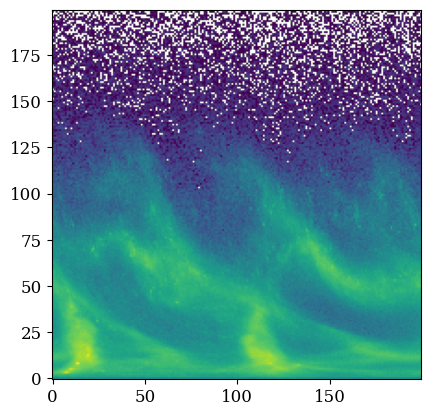

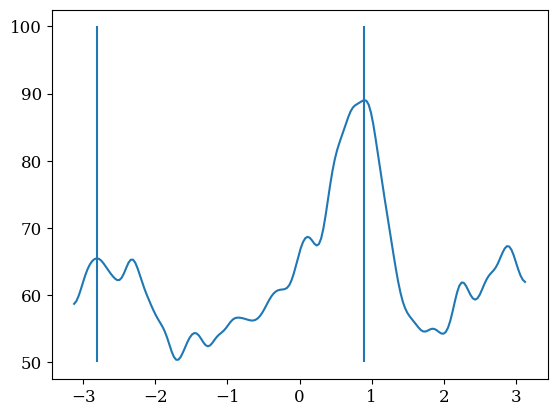

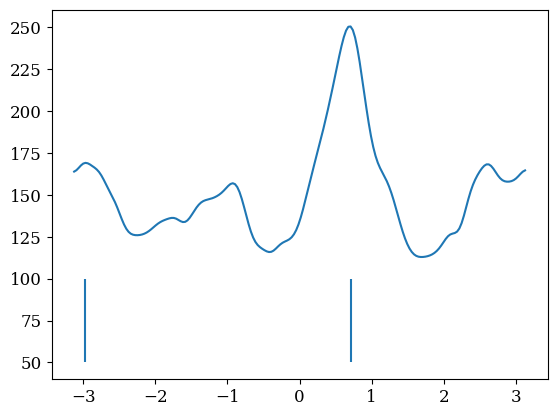

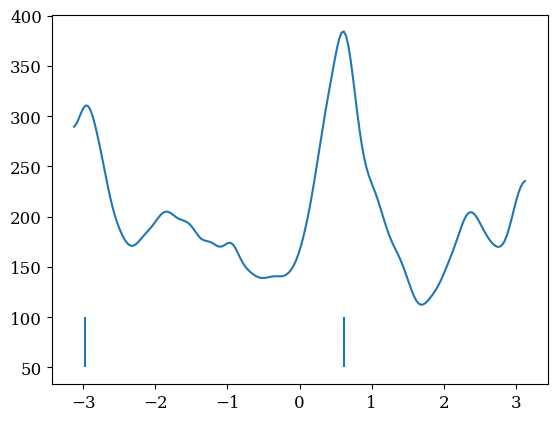

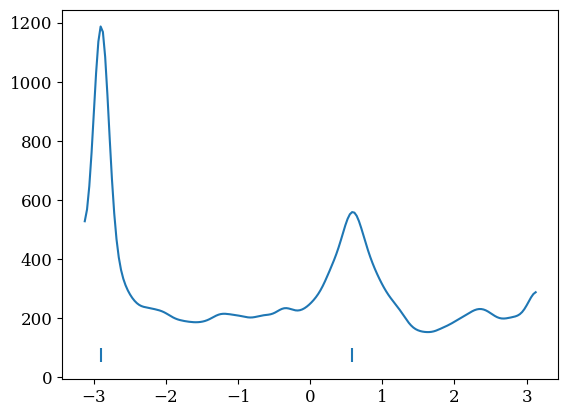

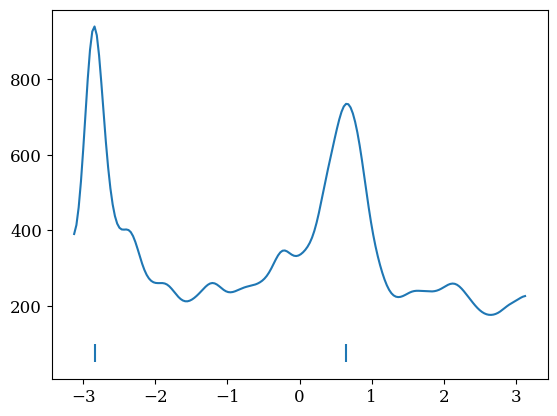

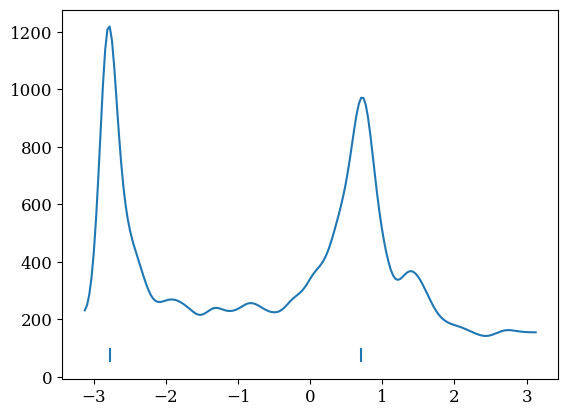

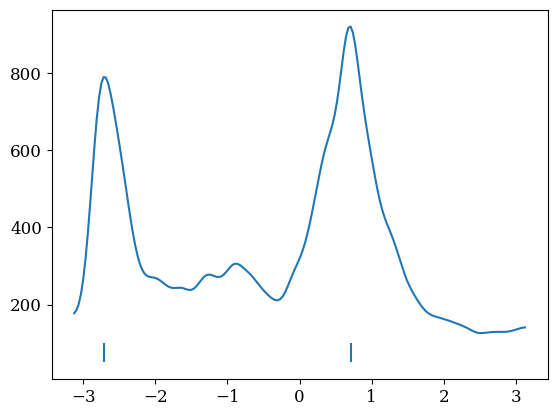

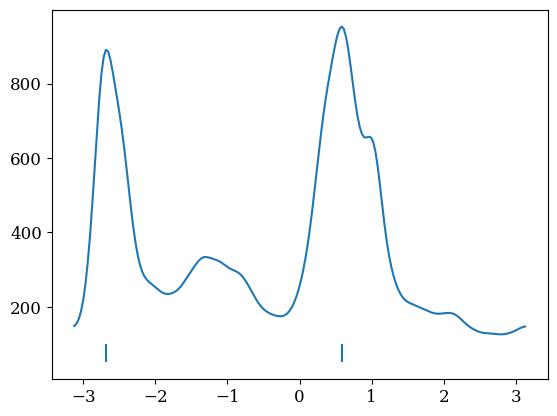

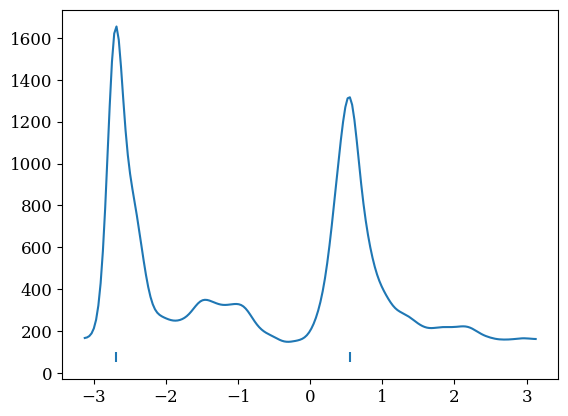

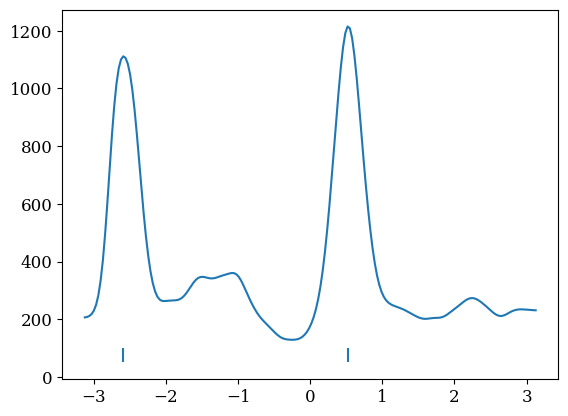

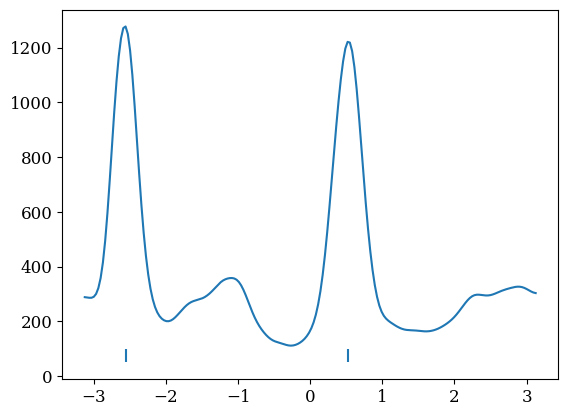

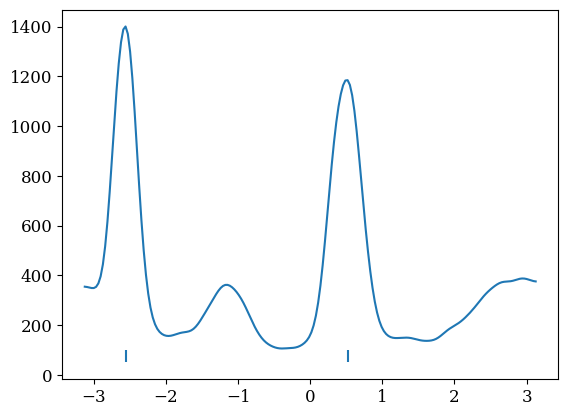

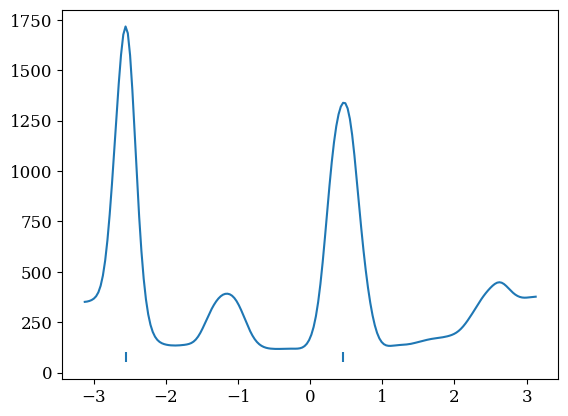

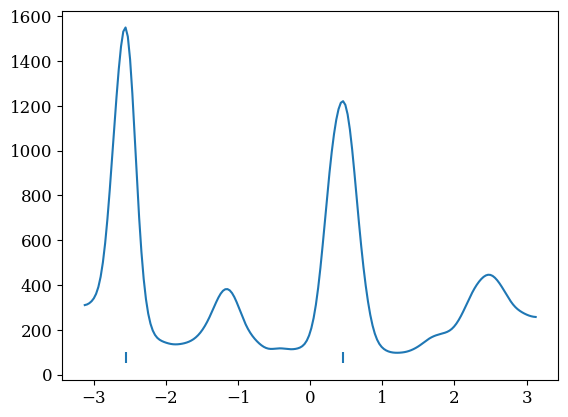

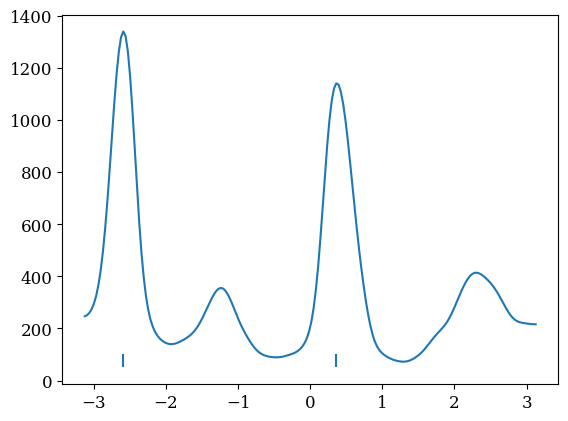

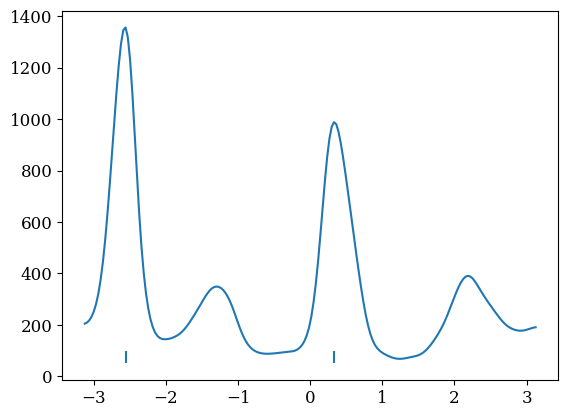

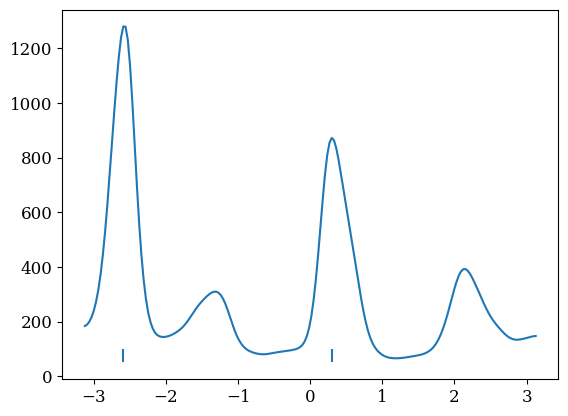

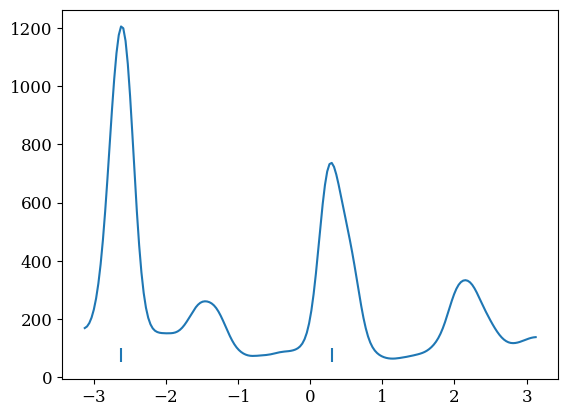

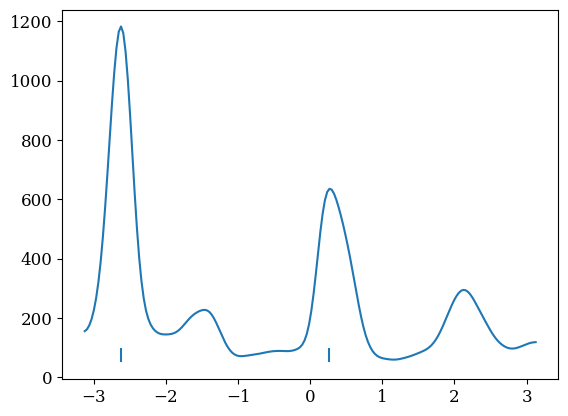

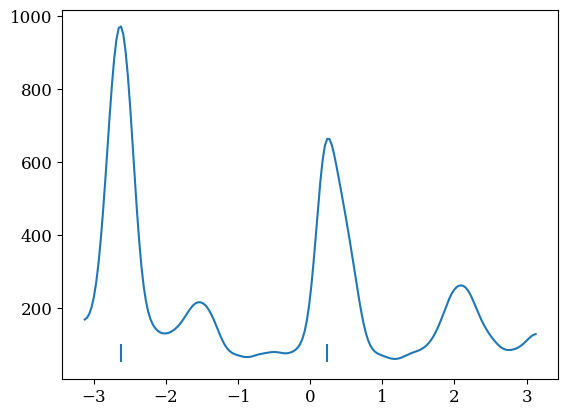

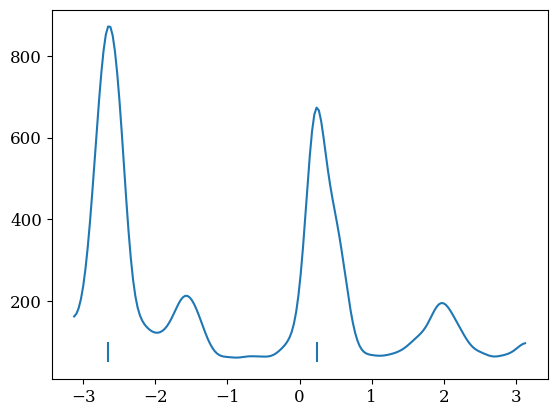

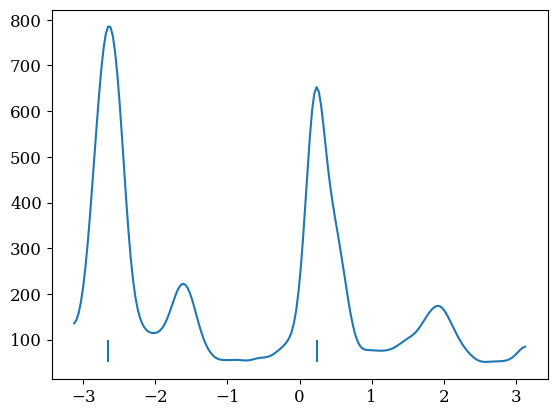

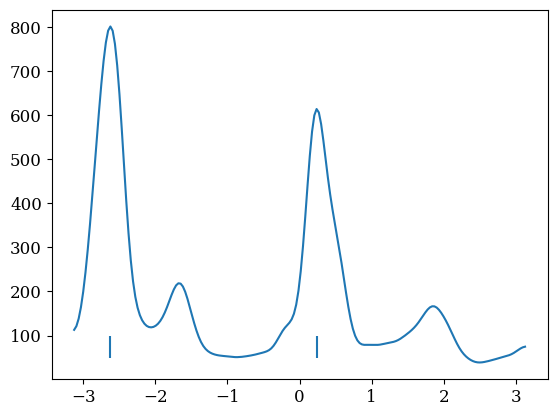

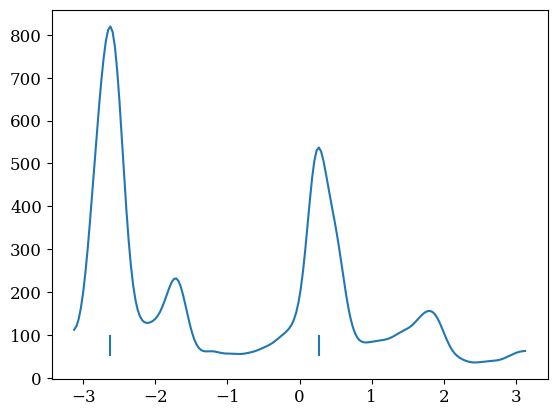

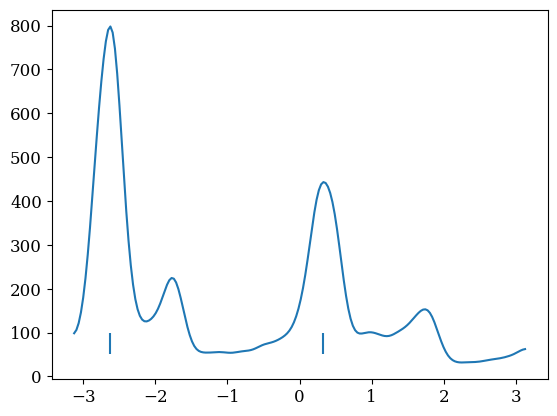

In [ ]:

for i, pq in enumerate(pq_names[40::5]):
    df = pd.read_parquet(pq_path + pq)
    radial_mask = df['rz'] < 15
    df = df[radial_mask]


    density, phi_edges, r_edges = np.histogram2d(df['phiz'], df['rz'], bins=(200, 200))
    phi_edges_avg = [np.mean(phi_edges[j:j+2]) for j in range(len(phi_edges)-1)]

    print(density.shape)
    fig, ax = plt.subplots()
    ax.imshow(density.T, norm='log', origin='lower')

    

    
    for j, r in enumerate(r_edges[:25]):
        r_density_slice = density[:, j]
        #print(len(r_density_slice))
        
        r_density_slice = gaussian_filter1d(r_density_slice, sigma=3)
        
        # index conversion, 200 indices is 2 pi so pi is 100 indices, so 3 is approx 95 indices
        # 200 indices is 15 kpc so 2 kpc is approx 26 indicex

        peaks = find_peaks(r_density_slice, distance=80)
        phi_peaks = [phi_edges_avg[j] for j in peaks[0]]


        fig, ax = plt.subplots()
        ax.plot(phi_edges_avg, r_density_slice)
        ax.vlines(phi_peaks, ymin=50, ymax=100)

        print(phi_peaks)
        
        
        

    break

